# Exercise 9.5 — Phase Space Trajectories of the Lorenz Equations

## Problem

Draw trajectories of the states of the Lorenz equations in a 3-D phase space for several different values of $r$ while keeping the other parameters constant. Observe how the dynamics change as $r$ is varied.

## The Lorenz Equations

$$\frac{dx}{dt} = \sigma(y - x)$$

$$\frac{dy}{dt} = rx - y - xz$$

$$\frac{dz}{dt} = xy - bz$$

**Fixed parameters:** $\sigma = 10$, $b = 8/3$. The parameter $r$ (the Rayleigh number) is varied.

### Equilibria

| Equilibrium | Coordinates | Exists | Stable |
|:-----------:|:-----------:|:------:|:------:|
| Origin $O$ | $(0,\,0,\,0)$ | always | $r < 1$ |
| $C^{\pm}$ | $\left(\pm\sqrt{b(r-1)},\;\pm\sqrt{b(r-1)},\;r-1\right)$ | $r > 1$ | $1 < r < r_H$ |

The **Hopf bifurcation** threshold is:

$$r_H = \frac{\sigma(\sigma + b + 3)}{\sigma - b - 1} = \frac{10 \cdot 47/3}{19/3} = \frac{470}{19} \approx 24.74$$

For $r > r_H$, both $O$ and $C^{\pm}$ are unstable and the system exhibits a **strange attractor**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sigma = 10.0
b     = 8.0 / 3.0
r_H   = sigma * (sigma + b + 3) / (sigma - b - 1)   # ≈ 24.74

def lorenz_rhs(t, s, r):
    x, y, z = s
    return [sigma*(y - x),
            r*x - y - x*z,
            x*y - b*z]

def c_pm(r):
    """Return the two non-trivial fixed points C+ and C- for r > 1."""
    c = np.sqrt(b * (r - 1))
    return np.array([c, c, r-1]), np.array([-c, -c, r-1])

def run(r, ic, t_end, n=8000):
    """Integrate the Lorenz system and return (t, xyz) arrays."""
    sol = solve_ivp(lorenz_rhs, [0, t_end], ic, args=(r,),
                    max_step=0.005, rtol=1e-9, atol=1e-12, dense_output=True)
    t = np.linspace(0, t_end, n)
    return t, sol.sol(t)

print(f"σ = {sigma},  b = {b:.4f}")
print(f"Pitchfork bifurcation at  r = 1")
print(f"Hopf bifurcation at       r_H = {r_H:.4f}")

σ = 10.0,  b = 2.6667
Pitchfork bifurcation at  r = 1
Hopf bifurcation at       r_H = 24.7368


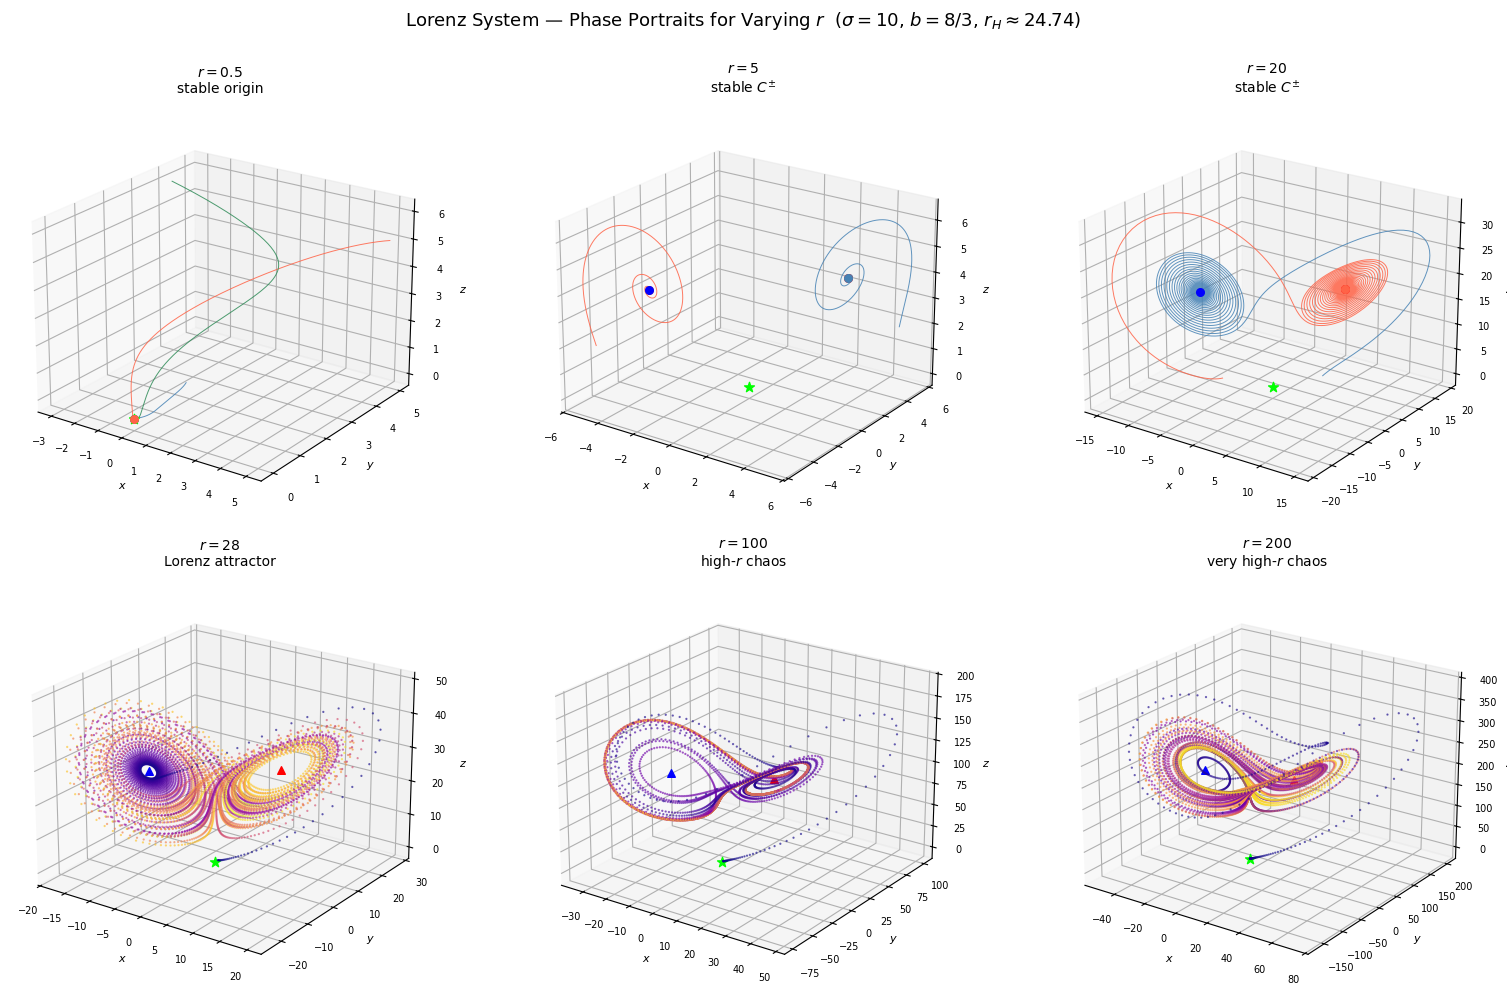

In [2]:
# ── 6-panel phase portrait overview ────────────────────────────────────────
#
#  Convergent regimes (r < r_H): multiple initial conditions shown in distinct
#  colors to illustrate convergence to the attracting fixed point(s).
#  Chaotic regimes (r ≥ r_H): single trajectory, scatter-colored by time.
#
#  Fixed-point markers:
#    ★ green  = origin O
#    ● red    = C+  (filled = stable, △ = unstable)
#    ● blue   = C-  (same convention)

r_cases = [
    (0.5,  20, [[1,1,1],[5,5,5],[-3,4,6]],   '$r=0.5$\nstable origin'),
    (5.0,  25, [[5,5,2],[-5,-5,2]],            '$r=5$\nstable $C^{\\pm}$'),
    (20.0, 50, [[5,5,2],[-5,-5,2]],            '$r=20$\nstable $C^{\\pm}$'),
    (28.0, 60, [[0,1,0]],                       '$r=28$\nLorenz attractor'),
    (100., 25, [[0,1,0]],                       '$r=100$\nhigh-$r$ chaos'),
    (200., 15, [[0,1,0]],                       '$r=200$\nvery high-$r$ chaos'),
]

palette = ['steelblue', 'tomato', 'seagreen']

fig = plt.figure(figsize=(16, 10))

for panel, (r, t_end, ics, title) in enumerate(r_cases):
    ax = fig.add_subplot(2, 3, panel + 1, projection='3d')

    if len(ics) == 1:
        # Chaotic regime — single long trajectory, colored by time
        t_eval, xyz = run(r, ics[0], t_end, n=12000)
        idx = np.arange(0, 12000, 2)
        ax.scatter(xyz[0, idx], xyz[1, idx], xyz[2, idx],
                   c=t_eval[idx], cmap='plasma', s=0.4, alpha=0.6)
    else:
        # Convergent regime — each IC in a distinct color
        for k, ic in enumerate(ics):
            t_eval, xyz = run(r, ic, t_end)
            ax.plot(xyz[0], xyz[1], xyz[2], lw=0.7,
                    color=palette[k], alpha=0.85)
            ax.scatter(*xyz[:, -1], color=palette[k], s=30, zorder=5)

    # Fixed-point markers
    ax.scatter(0, 0, 0, color='lime', s=55, marker='*', zorder=8)
    if r > 1:
        cp, cm = c_pm(r)
        is_stable = (r < r_H)
        mkr = 'o' if is_stable else '^'
        ax.scatter(*cp, color='red',  s=30, marker=mkr, zorder=7)
        ax.scatter(*cm, color='blue', s=30, marker=mkr, zorder=7)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$', fontsize=8, labelpad=1)
    ax.set_ylabel('$y$', fontsize=8, labelpad=1)
    ax.set_zlabel('$z$', fontsize=8, labelpad=1)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=22, azim=-55)

fig.suptitle(
    f'Lorenz System — Phase Portraits for Varying $r$'
    f'  ($\\sigma=10$, $b=8/3$, $r_H\\approx{r_H:.2f}$)',
    fontsize=13, y=1.0
)
plt.tight_layout()
plt.show()

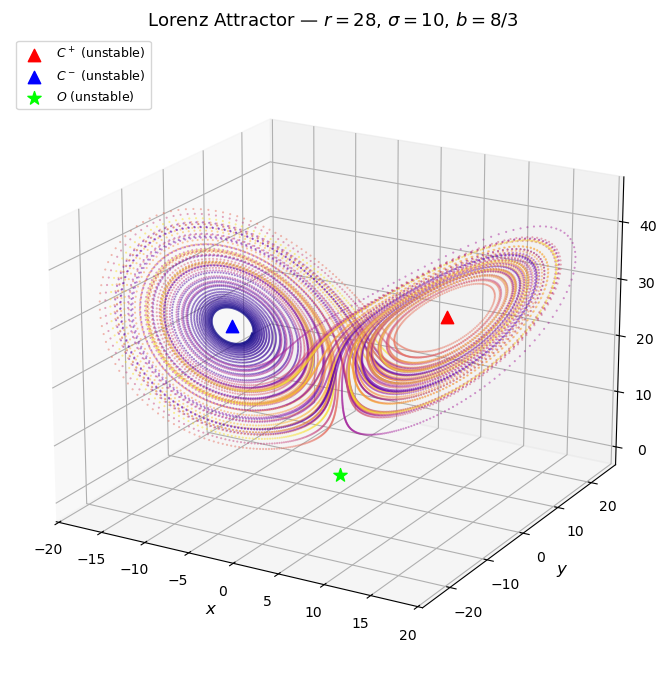

In [3]:
# ── Detailed Lorenz attractor at r = 28 ─────────────────────────────────────
# Long integration; first 5 time units discarded as transient.
# C± and O are marked as unstable (triangles) to show all fixed points
# are repelling, yet the trajectory stays bounded — the essence of the
# strange attractor.

t_eval, xyz = run(28.0, [0, 1, 0], t_end=80, n=40000)
mask = t_eval > 5
idx  = np.where(mask)[0][::2]

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

sc = ax.scatter(xyz[0, idx], xyz[1, idx], xyz[2, idx],
                c=t_eval[idx], cmap='plasma', s=0.25, alpha=0.5)

cp, cm = c_pm(28.0)
ax.scatter(*cp, color='red',  s=80, marker='^', zorder=8, label='$C^+$ (unstable)')
ax.scatter(*cm, color='blue', s=80, marker='^', zorder=8, label='$C^-$ (unstable)')
ax.scatter(0, 0, 0, color='lime', s=100, marker='*', zorder=8, label='$O$ (unstable)')

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_zlabel('$z$', fontsize=12)
ax.set_title('Lorenz Attractor — $r=28$, $\\sigma=10$, $b=8/3$', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

## Discussion — How Dynamics Change as $r$ Increases

### $r < 1$ — Stable Origin  *(e.g., $r = 0.5$)*

The origin $O = (0,0,0)$ is the only equilibrium and it is globally stable. All trajectories, regardless of initial condition, converge directly to zero. The phase portrait shows simple curves spiraling/decaying inward toward $O$. Physically this corresponds to damped, non-convective flow — the fluid just settles.

### $r = 1$ — Pitchfork Bifurcation

The origin loses stability and two new stable fixed points $C^{\pm}$ are born at $\left(\pm\sqrt{b(r-1)},\;\pm\sqrt{b(r-1)},\;r-1\right)$. The system transitions from one attractor to two.

### $1 < r < r_H \approx 24.74$ — Stable $C^{\pm}$  *(e.g., $r = 5$, $r = 20$)*

$C^{+}$ and $C^{-}$ are stable spirals. Trajectories converge to whichever one they are closest to at the start — the origin acts as an unstable saddle separating the two basins of attraction. As $r$ increases toward $r_H$, the approach becomes more oscillatory: trajectories take increasingly longer, winding paths (longer transients) before settling onto $C^{\pm}$. The eigenvalues of the Jacobian at $C^{\pm}$ are approaching the imaginary axis, signaling the coming Hopf bifurcation.

### $r = r_H \approx 24.74$ — Hopf Bifurcation

$C^{\pm}$ lose stability as their eigenvalues cross the imaginary axis. A strange attractor — one that is neither a fixed point, a limit cycle, nor a torus — emerges.

### $r = 28$ — The Lorenz Butterfly (Strange Attractor)

This is the classic chaotic regime. All three fixed points ($O$, $C^{+}$, $C^{-}$) are now unstable, yet the trajectory is bounded and never repeats. It traces the iconic butterfly shape, spiraling outward on one wing, crossing to the other, spiraling outward there, crossing back — forever, without period. Tiny differences in initial conditions grow exponentially (positive Lyapunov exponent), which is the hallmark of chaos. Despite the apparent randomness, the orbit is confined to the same geometric attractor for any initial condition.

### $r = 100$, $r = 200$ — High-$r$ Chaos

The attractor persists but changes shape as $r$ grows. The fixed points $C^{\pm}$ move to higher $z$ (at $z = r - 1$) and the trajectory has to travel farther in phase space to loop around them. The wings of the butterfly stretch out and the orbits become more elongated. The system remains chaotic (positive Lyapunov exponent), but the geometry of the strange attractor is qualitatively different from the classic $r = 28$ case. Within this high-$r$ range there are narrow periodic windows, similar to those seen in 1D discrete chaotic maps.

### Summary

| $r$ | All Fixed Points | Phase Portrait | Behavior |
|:---:|:----------------:|:--------------:|:--------:|
| $r < 1$ | $O$ stable | Decay to origin | Stable equilibrium |
| $1 < r < r_H$ | $C^{\pm}$ stable | Spirals to $C^+$ or $C^-$ | Two-basin convergence |
| $r = r_H$ | All unstable | — | Hopf bifurcation |
| $r \approx 28$ | All unstable | Butterfly attractor | Deterministic chaos |
| $r \gg r_H$ | All unstable | Stretched butterfly | High-$r$ chaos |